# Merge-site patches from `metrics_out` (794495)

Reads the OFFICIAL merge errors that `segmentation-skeleton-metrics` found for 794495
(`metrics_out/794495/.../merge_sites.csv`), centers a patch on each merge site, and plots
three views of that patch:

  1. **Raw image MIP** (fluorescence),
  2. **Fragments** — the segmentation skeleton, coloured by connected component,
  3. **Ground truth** — the GT skeleton, coloured by GT neuron.

Each merge site is one segmentation `Segment_ID` that the metric flagged as straying onto a
GT neuron (`GroundTruth_ID`). So the patch should show the fragment (fragments view) sitting
across ≥2 GT neurons (GT view) — the merge.

**Coordinate frame.** The CSV `Voxel=(c0,c1,c2)` is SWC-column order and `World=Voxel[::-1]*aniso`
(metrics `LabeledGraph` frame). The agentic viz cache (`bd`) stores voxels as `(c2,c1,c0)`, which
is exactly what the image reader / `nodes_in_patch` want — i.e. **center_voxel(z,y,x) =
reverse(CSV Voxel)**. The notebook VERIFIES this by checking the flagged `Segment_ID` actually
lands in the patch, and auto-tries fallbacks if not (so a frame slip can't silently mislead).

Big-memory node (the *_add cache is ~2.3 GB), `panda` env.

## 0. Setup — load merge_sites.csv + the viz cache

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

PROJ = Path("../..").resolve()
sys.path.insert(0, str(PROJ))
sys.path.insert(0, str(PROJ.parent / "segmentation-skeleton-metrics" / "src"))
from agentic_neuron_proofreader.utils import img_util
from agentic_neuron_proofreader.data_modules.datasets import BrainDataset

# --- params -------------------------------------------------------------------
BRAIN = "794495"
MCL   = 100
PATCH = 160          # receptive-field cube side (voxels)
SEG   = "raw.unet_449_792_202_splits_and_merges_831600"   # metrics_out segmentation subdir
WITH_IMAGE = True    # render the raw fluorescence MIP (needs the GCS reader)

CSV = PROJ / "metrics_out" / BRAIN / SEG / "merge_sites.csv"
merges = pd.read_csv(CSV)
# Parse the "(x, y, z)" string tuples into numeric arrays.
def _parse_tuple(s):
    return tuple(float(x) for x in str(s).strip("()[] ").split(","))
merges["Voxel_t"] = merges["Voxel"].map(_parse_tuple)
merges["World_t"] = merges["World"].map(_parse_tuple)
print(f"{len(merges)} merge sites in {CSV.name}")
print(merges[["Merge_ID", "Segment_ID", "GroundTruth_ID", "Voxel", "World"]].head())

# Viz cache (*_add.pkl): agentic SkeletonGraph (fragments + GT) + GCS image reader.
bd = BrainDataset.load_from_cache(f"../../cache/dataset_cache_{BRAIN}_mcl{MCL}_add.pkl")
fr_viz, gt_viz = bd.fragments_graph, bd.gt_graph
aniso = fr_viz.anisotropy
PATCH_SHAPE = (PATCH, PATCH, PATCH)
print(f"viz cache: fragments={fr_viz.number_of_nodes()} nodes, GT={gt_viz.number_of_nodes()} nodes, aniso={tuple(aniso)}")

168 merge sites in merge_sites.csv
      Merge_ID   Segment_ID  GroundTruth_ID                  Voxel  \
0  merge-1.swc  25110384161  N017-794495-IG  (46642, 33123, 13520)   
1  merge-2.swc  22999777822  N017-794495-IG  (48913, 33837, 11894)   
2  merge-3.swc  25593377852  N017-794495-IG  (41331, 29663, 14254)   
3  merge-4.swc  25593377852  N017-794495-IG  (41260, 29617, 13819)   
4  merge-5.swc  24567145326  N017-794495-IG  (48986, 32249, 12126)   

                           World  
0   (10112.96, 24776.0, 46642.0)  
1   (8896.71, 25310.08, 48913.0)  
2  (10661.99, 22187.92, 41331.0)  
3  (10336.61, 22153.52, 41260.0)  
4   (9070.25, 24122.25, 48986.0)  
viz cache: fragments=20876161 nodes, GT=1363808 nodes, aniso=(np.float64(0.748), np.float64(0.748), np.float64(1.0))


## 1. Center a patch on a merge site (with frame verification)

`center_voxel(z,y,x) = reverse(CSV Voxel)`. `_center_for(row)` returns that center AND verifies
the flagged `Segment_ID` actually appears among the fragment nodes in the resulting patch; if
the primary center misses, it tries fallbacks (`to_voxels(World)`, raw `Voxel`) and uses the
first that lands the segment — printing which frame worked.

In [2]:
def _seg_in_patch(center_voxel, segment_id):
    """(offset, # fragment nodes of `segment_id` inside the PATCH_SHAPE window)."""
    offset = tuple(int(c) - d // 2 for c, d in zip(center_voxel, PATCH_SHAPE))
    nodes, node_ids = fr_viz.nodes_in_patch(offset, PATCH_SHAPE, return_ids=True)[:2]
    seg = str(segment_id)
    cnt = sum(1 for n in node_ids if str(fr_viz.node_segment_id(int(n))) == seg)
    return offset, cnt

def _center_for(row):
    """Return (center_voxel (z,y,x), offset, note). Primary = reverse(CSV Voxel); verify the
    Segment_ID lands in-patch, else fall back through alternative frames."""
    vox = row["Voxel_t"]; world = row["World_t"]; seg = row["Segment_ID"]
    cands = [("reverse(Voxel)", tuple(int(v) for v in vox[::-1])),
             ("to_voxels(World)", tuple(img_util.to_voxels(tuple(world), aniso))),
             ("raw Voxel",        tuple(int(v) for v in vox))]
    best = None
    for name, cv in cands:
        offset, cnt = _seg_in_patch(cv, seg)
        if cnt > 0:
            return cv, offset, f"{name} (Segment_ID nodes in patch: {cnt})"
        if best is None:
            best = (cv, offset, f"NO frame landed Segment_ID — using {name} (patch may be off)")
    return best

# quick check on the first row
_row0 = merges.iloc[0]
_cv, _off, _note = _center_for(_row0)
print(f"row 0: merge {_row0['Merge_ID']}  Segment_ID {_row0['Segment_ID']}  "
      f"GT {_row0['GroundTruth_ID']}")
print(f"  center_voxel(z,y,x)={_cv}  ->  {_note}")

row 0: merge merge-1.swc  Segment_ID 25110384161  GT N017-794495-IG
  center_voxel(z,y,x)=(13520, 33123, 46642)  ->  reverse(Voxel) (Segment_ID nodes in patch: 43)


## 2. Render one merge site — MIP + fragments + GT

Pick a row with `ROW` (0-based index into merge_sites.csv). Renders the raw image MIP, the
fragment skeleton (by component), and the GT skeleton (by neuron), each with the merge site
marked (yellow ✕). `plt.show` is suppressed around each skeleton plot so the ✕ marker lands
before the inline backend closes the figure.

=== merge merge-1.swc  Segment_ID 25110384161  GroundTruth_ID N017-794495-IG  added_cable 5503.57 µm ===
    center_voxel(z,y,x)=(13520, 33123, 46642)  [reverse(Voxel) (Segment_ID nodes in patch: 43)]
    fragment nodes/edges in patch: 70/67   GT nodes/edges: 24/23 over 1 GT neuron(s)
Raw image (MIP):


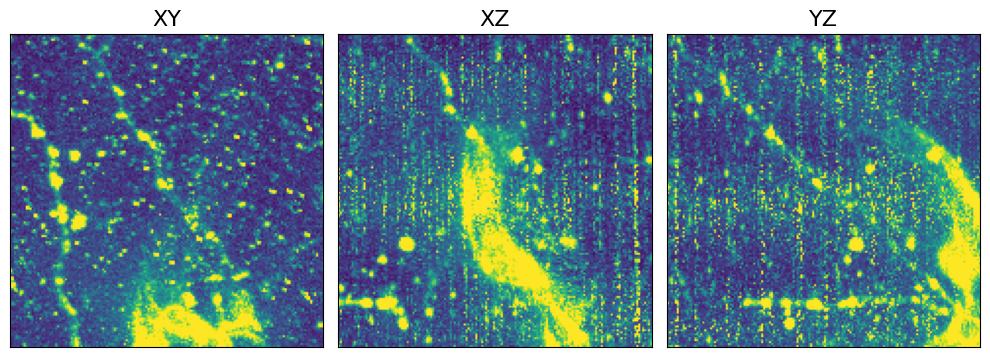

Fragments (by component); merge Segment_ID = 25110384161:


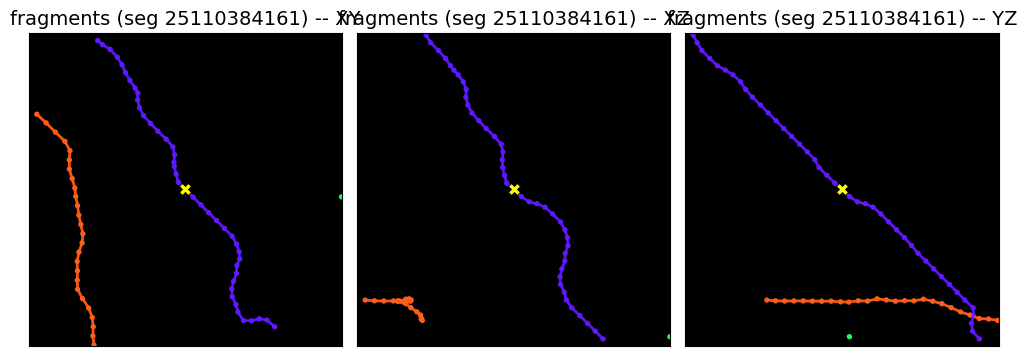

Ground truth (by neuron); flagged GroundTruth_ID = N017-794495-IG:


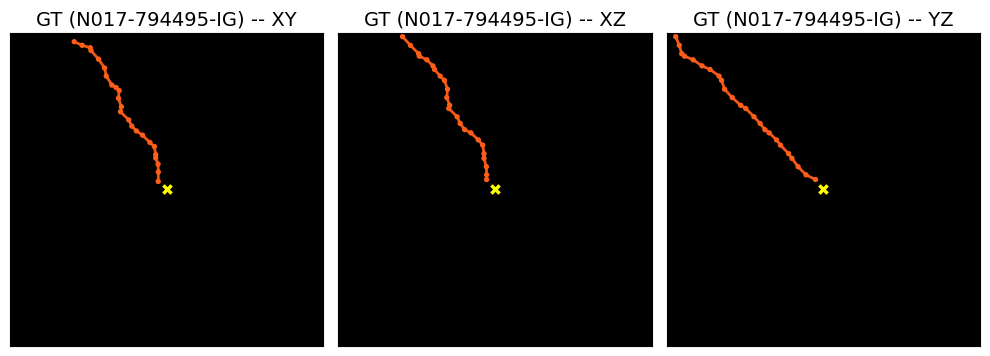


legend: yellow X = merge-site center (from metrics_out CSV)


In [3]:
ROW = 0    # which merge site (row index in merge_sites.csv)

def render_merge(row_idx):
    row = merges.iloc[row_idx]
    seg, gt_id = str(row["Segment_ID"]), row["GroundTruth_ID"]
    center_voxel, offset, note = _center_for(row)
    print(f"=== merge {row['Merge_ID']}  Segment_ID {seg}  GroundTruth_ID {gt_id}  "
          f"added_cable {row.get('Added Cable Length (μm)', float('nan'))} µm ===")
    print(f"    center_voxel(z,y,x)={center_voxel}  [{note}]")

    fr_nodes, fr_ncomp = fr_viz.nodes_in_patch(offset, PATCH_SHAPE, return_components=True)
    fr_edges, fr_ecomp = fr_viz.edges_in_patch(offset, PATCH_SHAPE, return_components=True)
    gt_nodes, gt_ncomp = gt_viz.nodes_in_patch(offset, PATCH_SHAPE, return_components=True)
    gt_edges, gt_ecomp = gt_viz.edges_in_patch(offset, PATCH_SHAPE, return_components=True)
    print(f"    fragment nodes/edges in patch: {len(fr_nodes)}/{len(fr_edges)}   "
          f"GT nodes/edges: {len(gt_nodes)}/{len(gt_edges)} over "
          f"{len(set(gt_ncomp)) if len(gt_ncomp) else 0} GT neuron(s)")

    # (1) raw image MIP
    if WITH_IMAGE:
        try:
            img_patch = np.squeeze(bd.img.read(center_voxel, PATCH_SHAPE))
            print("Raw image (MIP):"); img_util.plot_mips(img_patch)
        except Exception as e:
            print(f"    [image read failed: {e}]")

    # marker: the merge-site center, in LOCAL patch voxels (z,y,x) - offset
    _c = np.asarray(center_voxel, float) - np.asarray(offset, float)
    plane_axes = [(1, 2), (0, 2), (0, 1)]      # (row a, col b) over local (z,y,x)
    def _mark():
        for ax, (a, b) in zip(plt.gcf().axes, plane_axes):
            ax.scatter([_c[b]], [_c[a]], c="yellow", marker="X", s=70,
                       edgecolors="black", linewidths=0.5, zorder=12)

    # (2) fragments, coloured by connected component
    print(f"Fragments (by component); merge Segment_ID = {seg}:")
    _rs = plt.show; plt.show = lambda *a, **k: None
    try:
        img_util.plot_skeleton_mips({
            f"fragments (seg {seg})": {"nodes": fr_nodes, "node_components": fr_ncomp,
                                       "edges": fr_edges, "components": fr_ecomp, "color": "red"},
        }, PATCH_SHAPE, separate_rows=True)
    finally:
        plt.show = _rs
    _mark(); plt.show()

    # (3) GT, coloured by neuron
    print(f"Ground truth (by neuron); flagged GroundTruth_ID = {gt_id}:")
    _rs = plt.show; plt.show = lambda *a, **k: None
    try:
        img_util.plot_skeleton_mips({
            f"GT ({gt_id})": {"nodes": gt_nodes, "node_components": gt_ncomp,
                              "edges": gt_edges, "components": gt_ecomp, "color": "lime"},
        }, PATCH_SHAPE, separate_rows=True)
    finally:
        plt.show = _rs
    _mark(); plt.show()

render_merge(ROW)
print("\nlegend: yellow X = merge-site center (from metrics_out CSV)")

## 3. (optional) Save the first N merge sites to PDFs

In [5]:
from matplotlib.backends.backend_pdf import PdfPages
N_SAVE = 10     # how many merge sites (rows 0..N-1) to render to PDF
OUT = PROJ / "proofreader_evolve" / f"metrics_merge_site_patches_{BRAIN}"
OUT.mkdir(parents=True, exist_ok=True)
_real_show = plt.show; plt.show = lambda *a, **k: None
try:
    for r in range(min(N_SAVE, len(merges))):
        plt.close("all")
        render_merge(r)
        figs = [plt.figure(n) for n in plt.get_fignums()]
        mid = str(merges.iloc[r]["Merge_ID"]).replace(".swc", "")
        seg = merges.iloc[r]["Segment_ID"]
        pdf_path = OUT / f"{mid}_seg{seg}.pdf"
        with PdfPages(pdf_path) as pdf:
            for f in figs:
                pdf.savefig(f, bbox_inches="tight")
        print(f"saved row {r} ({len(figs)} figs) -> {pdf_path}")
finally:
    plt.show = _real_show; plt.close("all")

=== merge merge-1.swc  Segment_ID 25110384161  GroundTruth_ID N017-794495-IG  added_cable 5503.57 µm ===
    center_voxel(z,y,x)=(13520, 33123, 46642)  [reverse(Voxel) (Segment_ID nodes in patch: 43)]
    fragment nodes/edges in patch: 70/67   GT nodes/edges: 24/23 over 1 GT neuron(s)
Raw image (MIP):
Fragments (by component); merge Segment_ID = 25110384161:
Ground truth (by neuron); flagged GroundTruth_ID = N017-794495-IG:
saved row 0 (3 figs) -> /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/exaspim-agent/exa-spim-agent/proofreader_evolve/metrics_merge_site_patches_794495/merge-1_seg25110384161.pdf
=== merge merge-2.swc  Segment_ID 22999777822  GroundTruth_ID N017-794495-IG  added_cable 17413.87 µm ===
    center_voxel(z,y,x)=(11894, 33837, 48913)  [reverse(Voxel) (Segment_ID nodes in patch: 57)]
    fragment nodes/edges in patch: 90/86   GT nodes/edges: 44/43 over 1 GT neuron(s)
Raw image (MIP):
Fragments (by component); merge Segment_ID = 22999777822:
Ground truth (by 

## 4. Notes

- **What a row is.** One `merge_sites.csv` row = one segmentation `Segment_ID` the metric
  flagged as merged onto GT neuron `GroundTruth_ID` (a leaf of that fragment strayed far from
  its matched GT and `verify_site` confirmed it). `Added Cable Length` is how much erroneous
  cable the merge added.
- **Reading the 3 views.** Fragments (red, by component) shows the segmentation piece that was
  flagged; GT (lime, by neuron) shows the true neuron(s) in that window — a real merge shows the
  fragment overlapping ≥2 GT neurons. The image MIP is the underlying fluorescence.
- **Frame check.** §1 prints which coordinate frame landed the Segment_ID in-patch. If it ever
  prints "NO frame landed Segment_ID", the patch is off — inspect the CSV row / anisotropy
  rather than trusting the picture.
- This reads the OFFICIAL metrics output — independent of `candidate_merge_sites` (the GT-free
  enumerator). These are GT-confirmed merges, not enumeration candidates.